Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
!pip install prophet -q
warnings.filterwarnings('ignore')

Load and Merge Data

In [30]:
# Load datasets (replace with actual paths after uploading to Colab)
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

# Merge datasets
data = pd.merge(train, features, on=['Store', 'Date'], how='left')
data = pd.merge(data, stores, on='Store', how='left')

# Check columns after merge to identify naming conflicts
print("Columns after merge:", data.columns.tolist())

# Resolve IsHoliday naming conflict if it exists
if 'IsHoliday_x' in data.columns and 'IsHoliday_y' in data.columns:
    # Ensure they are consistent (should be the same for matching Store and Date)
    if (data['IsHoliday_x'] == data['IsHoliday_y']).all():
        data['IsHoliday'] = data['IsHoliday_x']
        data.drop(columns=['IsHoliday_x', 'IsHoliday_y'], inplace=True)
    else:
        raise ValueError("Mismatch in IsHoliday_x and IsHoliday_y after merge!")
elif 'IsHoliday_x' in data.columns:
    data.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
    if 'IsHoliday_y' in data.columns:
        data.drop(columns=['IsHoliday_y'], inplace=True)
elif 'IsHoliday_y' in data.columns:
    data.rename(columns={'IsHoliday_y': 'IsHoliday'}, inplace=True)
    if 'IsHoliday_x' in data.columns:
        data.drop(columns=['IsHoliday_x'], inplace=True)

# Convert 'Date' to datetime and set as index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)

# Display first few rows
print("First few rows of merged data:")
print(data.head())

Columns after merge: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size']
First few rows of merged data:
            Store  Dept  Weekly_Sales  Temperature  Fuel_Price  MarkDown1  \
Date                                                                        
2010-02-05      1     1      24924.50        42.31       2.572        NaN   
2010-02-05     29     5      15552.08        24.36       2.788        NaN   
2010-02-05     29     6       3200.22        24.36       2.788        NaN   
2010-02-05     29     7      10820.05        24.36       2.788        NaN   
2010-02-05     29     8      20055.64        24.36       2.788        NaN   

            MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
Date                                                                 
2010-02-05        NaN        NaN        NaN        NaN  211.096

Exploratory Data Analysis

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 421570 entries, 2010-02-05 to 2012-10-26
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Weekly_Sales  421570 non-null  float64
 3   Temperature   421570 non-null  float64
 4   Fuel_Price    421570 non-null  float64
 5   MarkDown1     150681 non-null  float64
 6   MarkDown2     111248 non-null  float64
 7   MarkDown3     137091 non-null  float64
 8   MarkDown4     134967 non-null  float64
 9   MarkDown5     151432 non-null  float64
 10  CPI           421570 non-null  float64
 11  Unemployment  421570 non-null  float64
 12  Type          421570 non-null  object 
 13  Size          421570 non-null  int64  
 14  IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(10), int64(3), object(1)
memory usage: 48.6+ MB
None

Descriptive Statistics:
        

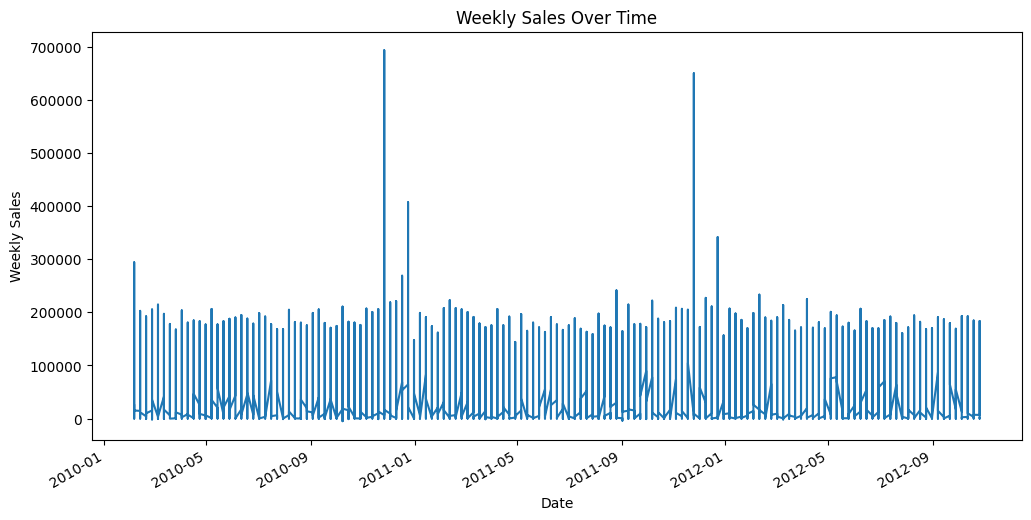

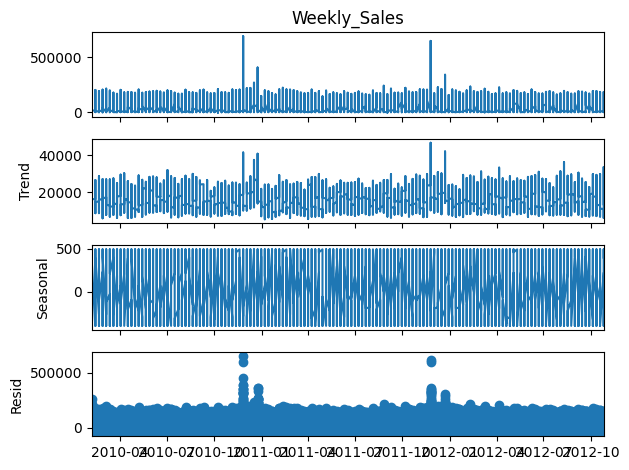

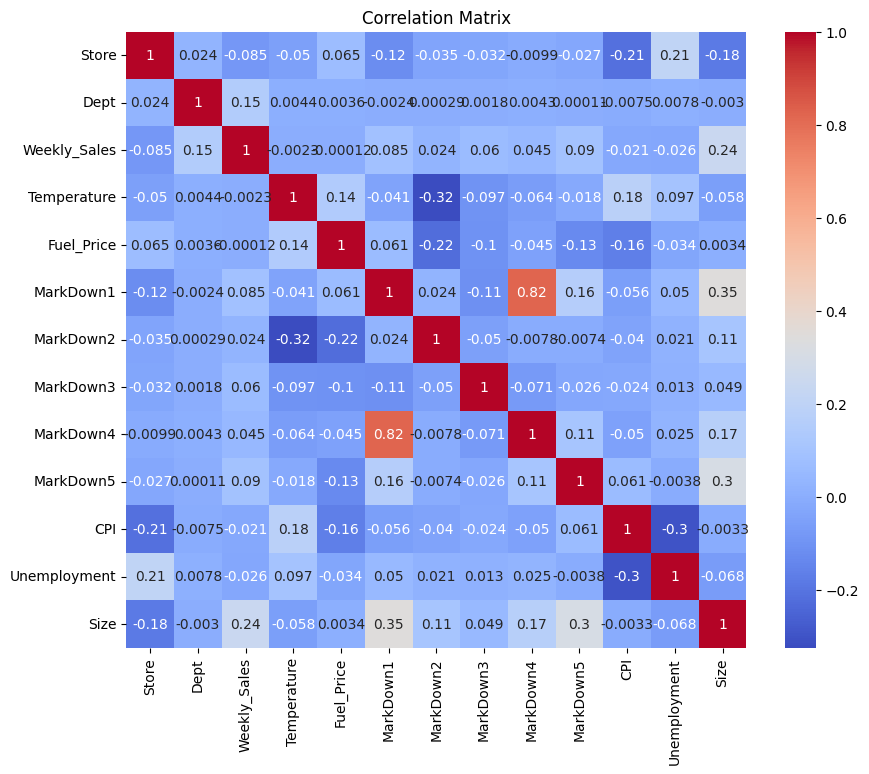

In [31]:
# Display data summary
print("Dataset Info:")
print(data.info())
print("\nDescriptive Statistics:")
print(data.describe())
print("\nMissing Values:")
print(data.isnull().sum())

# Plot Weekly Sales over time
plt.figure(figsize=(12, 6))
data['Weekly_Sales'].plot()
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.savefig('weekly_sales_plot.png')
plt.show()

# Seasonal decomposition (using a period of 52 weeks for yearly seasonality)
decomposition = seasonal_decompose(data['Weekly_Sales'].dropna(), model='additive', period=52)
decomposition.plot()
plt.savefig('seasonal_decomposition.png')
plt.show()

# Correlation matrix (only for numeric columns)
numeric_data = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

Data Preprocessing

In [32]:
# Drop markdown columns (high missing values)
data.drop(columns=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], inplace=True)

# Forward fill missing values
data.fillna(method='ffill', inplace=True)

# Convert categorical variables to numeric
# Remove drop_first=True to keep all dummy variables (Type_A, Type_B, Type_C)
data = pd.get_dummies(data, columns=['Type'], drop_first=False)

# Convert IsHoliday to integer
if 'IsHoliday' in data.columns:
    data['IsHoliday'] = data['IsHoliday'].astype(int)
else:
    raise KeyError("IsHoliday column not found after merge. Check the dataset and merge operation.")

# Verify no missing values remain
print("Missing Values After Preprocessing:")
print(data.isnull().sum())

# Verify dummy variables created
print("Columns after get_dummies:", data.columns.tolist())

Missing Values After Preprocessing:
Store           0
Dept            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Size            0
IsHoliday       0
Type_A          0
Type_B          0
Type_C          0
dtype: int64
Columns after get_dummies: ['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'IsHoliday', 'Type_A', 'Type_B', 'Type_C']


Feature Engineering

In [33]:
# Create lag features
data['Lag_1'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
data['Lag_2'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)

# Create rolling mean feature (shifted to avoid leakage)
data['Rolling_Mean_4'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.rolling(4, min_periods=1).mean().shift(1))

# Extract time-based features (reset index to access date components)
data = data.reset_index()
data['WeekOfYear'] = data['Date'].dt.isocalendar().week  # Use dt.week if isocalendar().week is deprecated
data['Month'] = data['Date'].dt.month
data['Quarter'] = data['Date'].dt.quarter

# Drop rows with NaN values created by lagging
data.dropna(inplace=True)

# Set 'Date' back as index
data.set_index('Date', inplace=True)

# Save processed data
data.to_csv('processed_data.csv')
print("Processed Data Shape:", data.shape)

Processed Data Shape: (414945, 18)


Split Data

In [34]:
# Split into training and testing sets
train_data = data[data.index < '2012-01-01']
test_data = data[data.index >= '2012-01-01']

# Verify shapes
print(f"Training Data Shape: {train_data.shape}")
print(f"Testing Data Shape: {test_data.shape}")

Training Data Shape: (287567, 18)
Testing Data Shape: (127378, 18)


Model Building - Random Forest

Random Forest - MAE: 1613.39, RMSE: 3557.60, MAPE: inf%


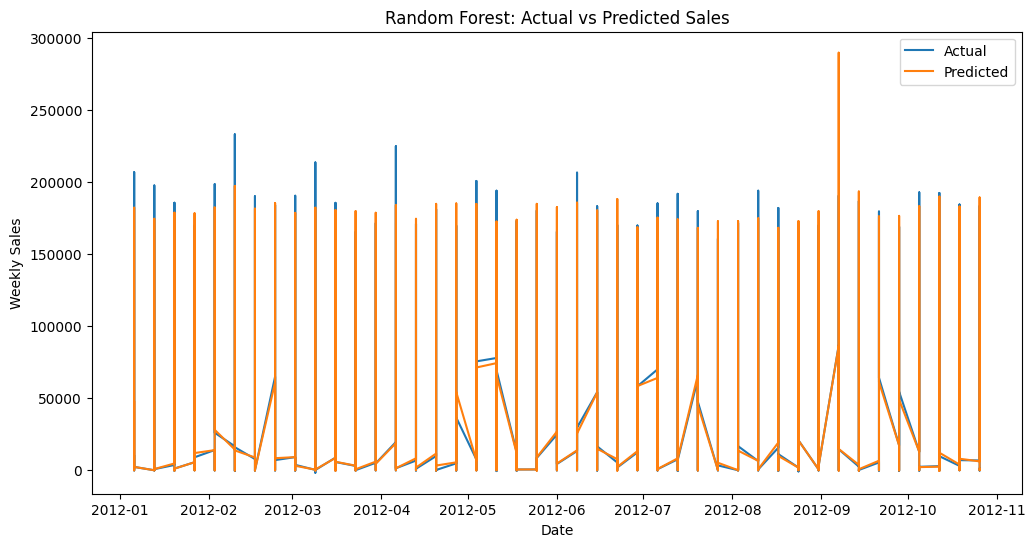

In [35]:
# Define features and target
features_to_use = ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                   'Lag_1', 'Lag_2', 'Rolling_Mean_4', 'WeekOfYear', 'Month', 'Quarter', 'Type_A', 'Type_B']
X_train = train_data[features_to_use]
y_train = train_data['Weekly_Sales']
X_test = test_data[features_to_use]
y_test = test_data['Weekly_Sales']

# Train Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Random Forest - MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, y_test, label='Actual')
plt.plot(test_data.index, y_pred, label='Predicted')
plt.title('Random Forest: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.savefig('rf_forecast.png')
plt.show()

Model Building - Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp4do8rdto/k07ac84r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp4do8rdto/rg4ay46w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12876', 'data', 'file=/tmp/tmp4do8rdto/k07ac84r.json', 'init=/tmp/tmp4do8rdto/rg4ay46w.json', 'output', 'file=/tmp/tmp4do8rdto/prophet_modelcjvq6y6e/prophet_model-20250503035229.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
03:52:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:52:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


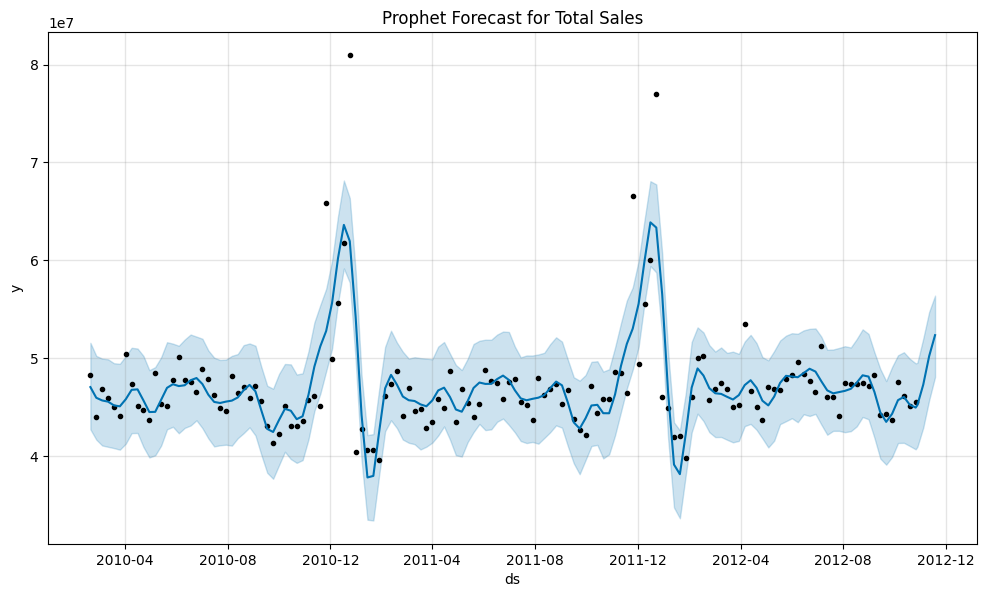

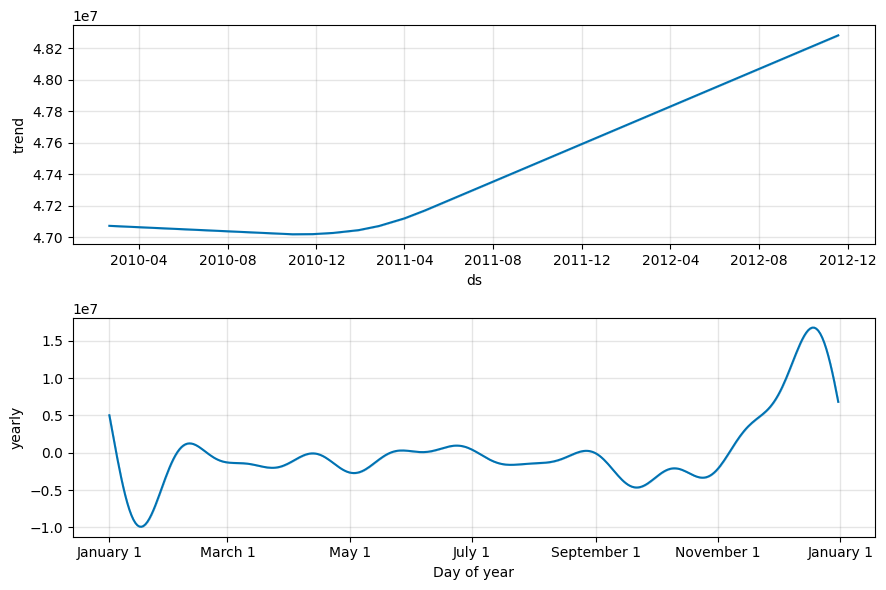

In [36]:
# Prepare data for Prophet (total sales across all stores and departments)
total_sales = data.groupby('Date')['Weekly_Sales'].sum().reset_index()
total_sales.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'}, inplace=True)

# Train Prophet model
model = Prophet()
model.fit(total_sales)

# Create future dataframe for predictions
future = model.make_future_dataframe(periods=4, freq='W')
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title('Prophet Forecast for Total Sales')
plt.savefig('prophet_forecast.png')
plt.show()

# Plot components
model.plot_components(forecast)
plt.savefig('prophet_components.png')
plt.show()

Stakeholder Presentation Summary

In [37]:
# Summary for stakeholders
print("Stakeholder Summary:")
print("- Problem: Predicting sales helps avoid overstocking or stockouts.")
print("- Approach: Used historical data and machine learning to forecast sales.")
print(f"- Results: Random Forest model predicts sales with MAE of {mae:.2f}.")
print("- Impact: Saves costs and improves customer satisfaction.")

Stakeholder Summary:
- Problem: Predicting sales helps avoid overstocking or stockouts.
- Approach: Used historical data and machine learning to forecast sales.
- Results: Random Forest model predicts sales with MAE of 1613.39.
- Impact: Saves costs and improves customer satisfaction.
